# Hyperparameter search for the learned controllers

`FIGURES_RL.ipynb` trains the three learned controllers — behaviour cloning of the
MILP (**IL**), a DQN from a cold start (**RL**), and the clone fine-tuned by the DQN
(**IL+RL**) — under settings that were chosen by hand and then checked on a 4-point
grid over two knobs at a time (`run_rl_benchmark.tune`). The clone's whole optimiser,
the network width and most of the DQN's knobs were never searched. This notebook
presents a joint search over them (`rl_hpo.py`, driven by `run_rl_hpo.py`) and asks
the only question that matters for the paper: **do the tuned settings save a
household more money in the test year than the settings the panel uses?**

### What is searched, and on what

| method | searched | held fixed |
|---|---|---|
| IL | learning rate, width, batch, weight decay, class-weight strength (0 = unweighted … 1 = inverse frequency), label smoothing, early-stop patience | the teacher, the features, the split |
| RL | learning rate, γ, n-step, batch, width, target sync, update interval, replay size, final ε, ε-decay share, reward scale, episode length | step budget (500k, early-stopped), evaluation cadence |
| IL+RL | the fine-tune: learning rate, γ, n-step, batch, target sync, ε-decay share, reward scale, BC regulariser and its decay, BC-guided exploration | the clone — the IL search's winner, its width and optimiser |

The sampler is TPE (multivariate, constant liar for parallel trials); the current
settings are enqueued as trial 0, the **incumbent**. Every RL trial is evaluated
household by household in rungs (3, then 8) and abandoned at the first rung if it
sits below the median of earlier trials there; IL trials are cheap (~1 s a fit) and
run on 16 households unpruned.

### Three stages, and what each one is allowed to see

1. **Search** — on households that are **not** study units: 8 (RL) or 16 (IL) other
   members of the k = 30 clustering, one per shape type. Each configuration is trained
   on the training blocks and scored on the 20 held-out validation weeks. The objective
   is the **validation saving against an idle battery**, net of lifetime wear,
   annualised and averaged over the households.
2. **Refine** — the incumbent and the three best configurations are re-trained under
   two more seeds on the same households; the winner is the best seed average. A search
   ranks single draws, and this learner's seed moves results coherently across
   households.
3. **Confirm** — the winner and the panel's current settings are trained on the **30
   study households** under three seeds and scored on the **test year** through the
   arm's own `run_policy` + settlement. This is the first time a tuned configuration
   meets the test year, and nothing is chosen from it.

The study households are never seen by the search or the refinement, so stage 3 is
held out twice over: other years and other households.

### Interrupting and resuming

Everything is checkpointed. Each (configuration, household, seed) training is a result
file keyed by its config digest; the optuna study is an append-only journal; a trial
the driver had open when it was stopped is re-queued with the same parameters on
restart. Stop the driver at any time (`kill <pid>`, Ctrl-C) and rerun the same command
(`python3 run_rl_hpo.py all --jobs 12`). **This notebook only reads**, and can be run
at any moment, including while the driver is running: it draws whatever is finished,
and every cell skips what does not exist yet.

### Promoting a winner

Nothing here changes the panel. `python3 run_rl_hpo.py report` prints the winners as
`run_rl_benchmark.TUNED` entries; pasting them and re-running the panel is the same
deliberate, reviewable step the grid's winners went through. Promote only a study
whose confirmation (section 5) says the gain is real.

In [1]:
import importlib

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon

import hems_study as hs
import figure_style as fs
import run_rl_benchmark as rb
import rl_hpo as hpo
hs, fs, rb, hpo = (importlib.reload(m) for m in (hs, fs, rb, hpo))

import Plotting_Functions as pf
pf = importlib.reload(pf)
pf.use(subdir="hems", titles=False)
from Plotting_Functions import INK, INK_2, MUTED, SURFACE, finish

TARIFFS = ("AU", "SI")
METHODS = ("bc", "bc_dqn", "dqn")
METHOD_NAME = {"bc": "IL", "bc_dqn": "IL+RL", "dqn": "RL"}


# A study's colour is its tariff's hue shaded by learner family, its marker the
# family's -- the same encoding every learned row has in FIGURES_RL.
def mcolor(tariff, method):
    return fs.ctrl_color(tariff, f"{method}_fc_h24")


def mmarker(method):
    return fs.ctrl_marker(f"{method}_fc_h24")


def study(tariff, method):
    name = f"{tariff}_{method}"
    return name if name in STUDIES else None


STUDIES = hpo.list_studies()
DRIVER = hpo.driver_running()
STATUS = hpo.status_frame()
print(f"results under {hpo.HPO_ROOT}")
print("driver:", f"RUNNING (pid {DRIVER['pid']}, since {DRIVER['started']}) -- "
      "this notebook shows a snapshot" if DRIVER else "not running")
if STATUS.empty:
    print("no studies yet: run `python3 run_rl_hpo.py all --jobs 12` first")
else:
    with pd.option_context("display.width", 200):
        print(STATUS.round(2).to_string(index=False))

/Users/summerscholl/Library/Python/3.14/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


results under /Users/summerscholl/Documents/ERK-2026/Main/results_local/rl_hpo
driver: not running
    study  households  complete  pruned  failed  running  waiting  incumbent_val  best_val    winner  winner_delta_val  confirmed_rows
    AU_bc          16       144       0       0        0        0         255.37    266.97 trial 135             10.39             180
AU_bc_dqn           8        23      17       0        0        0         286.12    287.39  trial 28              1.18             180
   AU_dqn           8        28      12       0        0        0         268.91    276.35  trial 29              5.52             180
    SI_bc          16       144       0       0        0        0          39.08     46.17  trial 59              7.07             180
SI_bc_dqn           8        12      28       0        0        0          49.65     50.12  trial 13              0.14             180
   SI_dqn           8        28      12       0        0        0          36.46     46.79 

## Results of the run of 2026-10-08

Full pipeline, 330 min on 12 workers: 144 trials per IL study on 16 households, 40 per
RL and IL+RL study on 8 (69 of the 160 pruned at the first rung), the top three and the
incumbent re-trained under three seeds, then 1,080 test-year runs on the 30 study
households. No evaluation failed.

**Test year, tuned minus current settings, per household and year (bill + wear, three
seeds averaged, 30 households; Holm over the six rows):**

| | AU (AUD/a) | SI (EUR/a) |
|---|---|---|
| IL | **+29.4** [14.8, 46.6], 25/30 better, p_holm < 0.001 | +3.4 [0.7, 6.2], 19/30, p_holm 0.09 |
| IL+RL | **+22.4** [12.8, 33.2], 26/30, p_holm < 0.001 | +7.0 [1.9, 12.5], 18/30, p_holm 0.11 |
| RL | **+10.7** [7.0, 14.3], 26/30, p_holm < 0.001 | **+17.3** [13.1, 21.5], 28/30, p_holm < 0.001 |

- **On AU, tuning pays for all three learners**, and the two clone-based ones clear even
  the conservative seed-noise band in section 5. The tuned local clone's +29 AUD/a is
  about the size of what pooling 299 households bought the clone
  (`FIGURES_RL_GLOBAL.ipynb`: +29.7 for the global clone over the same local one) —
  so part of the pooling gain was a better-conditioned fit, not data volume alone.
  That is a hypothesis to test (a tuned *pooled* clone), not a conclusion.
- **On SI, the large and robust gain is pure RL** (+17.3 EUR/a, 28/30): the tuned DQN
  cycles 131 EFC/a instead of 83, i.e. it stops under-trading — the failure mode
  `FIGURES_RL.ipynb` documented for the pure DQN on SI. The SI clone gains are
  positive but inside the noise of re-seeding the current model.
- **The validation weeks under-state the clone's test-year gain** (AU IL: +10.4 on
  validation, +29.4 on test) and over-state nothing — the same pattern the pooled
  study found, where held-out weeks inside the training years could not see a
  robustness gain the test year shows.
- **IL+RL's gain is mostly the clone's.** The fine-tune search moved validation by +1.2
  (AU) and +0.1 (SI, p 0.84) on top of the new clone; the IL+RL comparison here is
  "tuned clone + tuned fine-tune" against the panel's, and the clone is most of it.

**What the search learned about the clone.** Two settings explain almost all of the
variance (section 2): label smoothing and the strength of the class weighting. Their
effect is mostly whether the clone collapses to near-idle (0 saving): on AU every fit
with class-weight power between ~0.5 and ~0.9 collapses, while both ends work. The
winners on both tariffs are nearly unweighted (power 0.14 AU, 0.09 SI) with label
smoothing (0.05 / 0.1) and width 64. The comment in `rl_control.train_bc` says an
unweighted fit collapsed onto idle; on the current split and features it does not —
that comment would need revising if the winners are promoted. Why mid-range weights
collapse is not explained here.

**The DQN** depends mostly on learning rate and γ on both tariffs (section 2); the
winners use a lower learning rate than the panel (1.2–1.4 × 10⁻⁴ against 10⁻³), 14-day
episodes, and γ 0.994 (AU) / 0.9987 (SI).

**Caveats.** Every gain is against the panel's *current* settings at the panel's budget
(500k steps, early-stopped), on the deployable `fc_h24` features only; the forecast
ablations were not re-run under the tuned settings, so whether the value-of-information
results move is open. Selection used only non-study households' validation weeks; the
test year was read once.

## 1. Progress of the search

Each point is one trial's validation saving **minus the incumbent's on the same
households** (zero line = the current settings): a complete trial over all of the
study's households, a pruned one (hollow) over the first-rung households it was
stopped on. The step line is the best complete trial so far. Configurations that
collapse to an idle battery fall hundreds below zero; they are drawn on the dotted
floor and counted there, so they do not flatten the band that matters. A search that has found
nothing sits below zero throughout; one whose best line is still climbing at its last
trial was stopped early and is worth extending (`--trials`).

Validation savings are per year, annualised from the 140 held-out days, in the
tariff's currency.

findfont: Failed to find font weight semibold, now using 700.


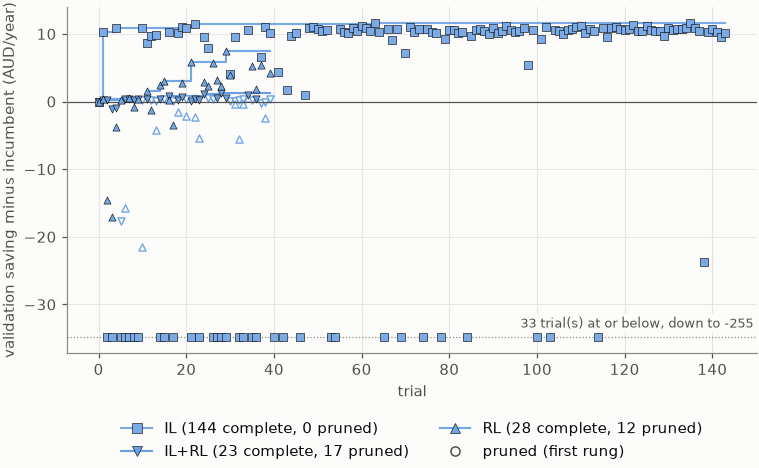

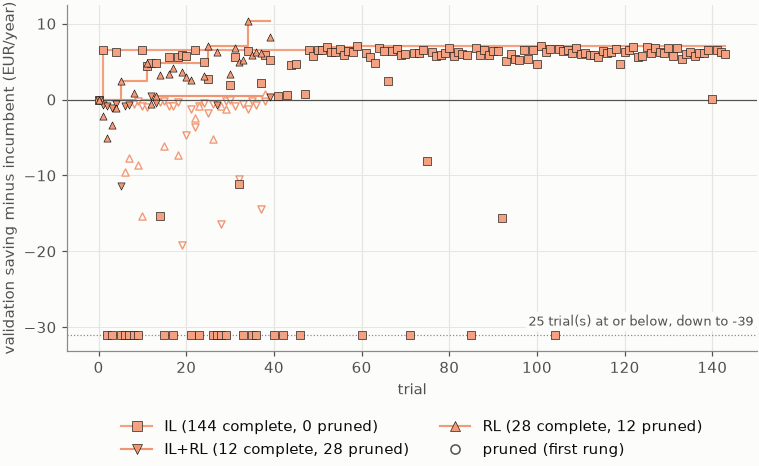

In [2]:
HIST = {n: hpo.history_frame(n) for n in STUDIES}
for tariff in TARIFFS:
    have = [m for m in METHODS if study(tariff, m) and not HIST[study(tariff, m)].empty]
    if not have:
        print(f"{tariff}: no finished trials yet")
        continue
    # A floor under the competitive band. Configurations that collapse to an
    # idle battery sit hundreds below zero and would flatten the band the
    # search is actually deciding in, so they are drawn ON the floor and
    # counted there, with their true minimum.
    best_abs = max(float(np.nan_to_num(HIST[study(tariff, m)].best.abs().max()))
                   for m in have)
    floor = -max(3.0 * best_abs, 10.0)
    fig, ax = plt.subplots()
    handles = []
    below, worst = 0, 0.0
    for m in have:
        h = HIST[study(tariff, m)]
        col = mcolor(tariff, m)
        y = h.delta.clip(lower=floor)
        below += int((h.delta < floor).sum())
        worst = min(worst, float(h.delta.min()))
        comp, prun = h.state == "COMPLETE", h.state == "PRUNED"
        ax.scatter(h.number[comp], y[comp], marker=mmarker(m), s=22, color=col,
                   edgecolor=INK, lw=0.4, zorder=3)
        ax.scatter(h.number[prun], y[prun], marker=mmarker(m), s=22,
                   facecolor=SURFACE, edgecolor=col, lw=0.9, zorder=2)
        ax.step(h.number, h.best, where="post", color=col, lw=1.4, zorder=1)
        handles.append(Line2D([], [], marker=mmarker(m), color=col, lw=1.4,
                              markeredgecolor=INK, markeredgewidth=0.4,
                              label=f"{METHOD_NAME[m]} ({int(comp.sum())} complete, "
                                    f"{int(prun.sum())} pruned)"))
    if below:
        ax.axhline(floor, color=MUTED, lw=0.8, ls=":")
        pf.edge_label(ax, floor, f"{below} trial(s) at or below, down to {worst:,.0f}",
                      side="right")
    handles.append(Line2D([], [], marker="o", ls="", markerfacecolor=SURFACE,
                          markeredgecolor=INK_2, label="pruned (first rung)"))
    ax.axhline(0, color=INK_2, lw=0.8)
    ax.grid(axis="y", color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    pf.key_legend(ax, handles, where="below", ncol=2)
    finish(ax, title=f"{tariff}: search progress against the current settings",
           xlabel="trial",
           ylabel=f"validation saving minus incumbent ({hs.money(tariff, 'year')})")
    pf.show(fig, f"rlhpo_history_{tariff.lower()}")

## 2. Which settings matter

fANOVA importance over the complete trials: the share of the variance in validation
saving each parameter explains on its own. Shown only once a study has 12 complete
trials — below that a random forest over the trials is a guess. A parameter near zero
on both tariffs can be left at whatever value is convenient; one that dominates is
where the panel's setting deserves a justification in the text.

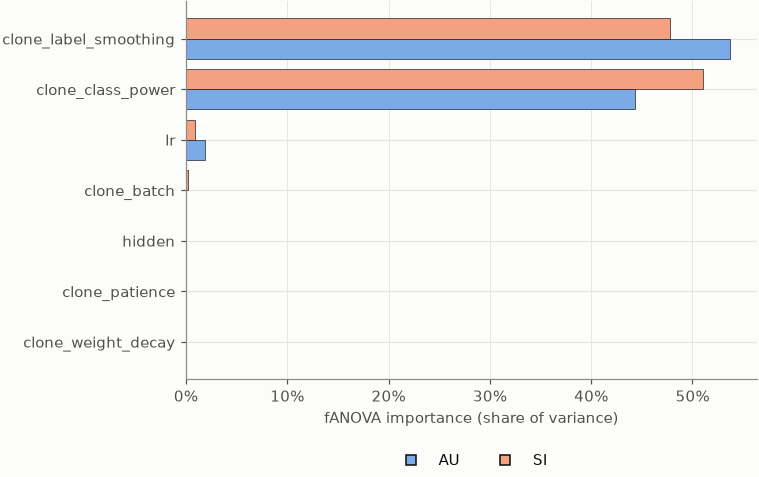

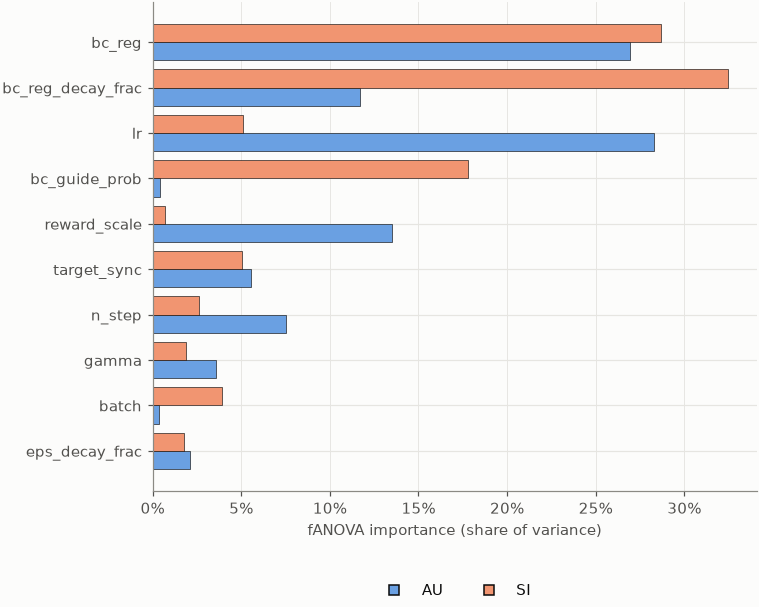

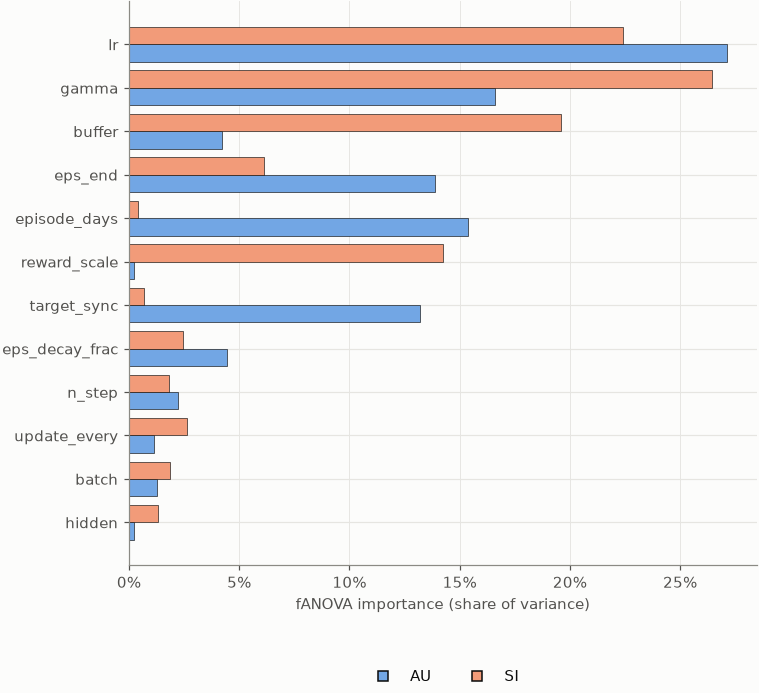

In [3]:
IMP = {}
for n in STUDIES:
    try:
        IMP[n] = hpo.importance_frame(n)
    except Exception as exc:          # degenerate study (one value everywhere)
        print(f"{n}: importance not computable ({exc})")
for m in METHODS:
    frames = [IMP[study(t, m)].assign(tariff=t) for t in TARIFFS
              if study(t, m) in IMP and not IMP[study(t, m)].empty]
    if not frames:
        print(f"{METHOD_NAME[m]}: fewer than 12 complete trials on every tariff")
        continue
    df = pd.concat(frames)
    order = (df.groupby("param")["importance"].mean().sort_values().index.tolist())
    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.25 + 0.055 * len(order)))
    y = np.arange(len(order))
    tars = [t for t in TARIFFS if t in set(df.tariff)]
    hgt = 0.8 / len(tars)
    for k, t in enumerate(tars):
        v = df[df.tariff == t].set_index("param")["importance"].reindex(order)
        ax.barh(y + (k - (len(tars) - 1) / 2) * hgt, 100 * v.fillna(0), height=hgt,
                color=mcolor(t, m), edgecolor=INK, lw=0.4, label=t)
    ax.set_yticks(y)
    ax.set_yticklabels(order)
    ax.xaxis.set_major_formatter(pf.PCT)
    ax.grid(axis="x", color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    pf.key_legend(ax, [Line2D([], [], marker="s", ls="", color=mcolor(t, m),
                              markeredgecolor=INK, label=t) for t in tars],
                  where="below", ncol=2)
    finish(ax, title=f"{METHOD_NAME[m]}: what the validation saving depends on",
           xlabel="fANOVA importance (share of variance)", ylabel="")
    pf.show(fig, f"rlhpo_importance_{m}")

## 3. The objective against each setting

One panel per parameter, the six most important first: every complete trial's
validation saving against the value it used, the incumbent ringed. Logarithmic axes
for the parameters searched on a log scale. A flat cloud says the setting does not
matter on these households; a ridge with the incumbent on its flank says the panel's
value is off the optimum.

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


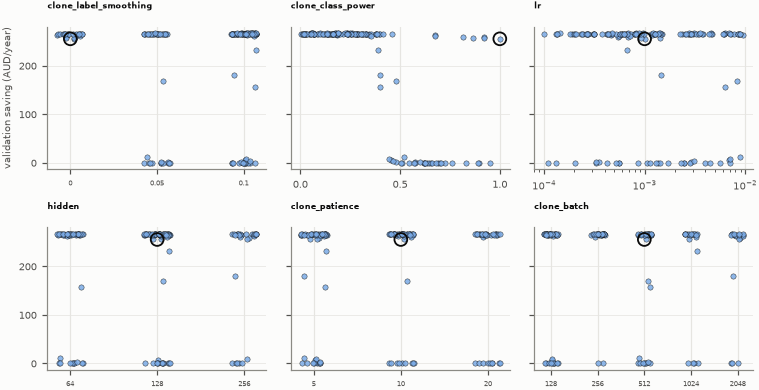

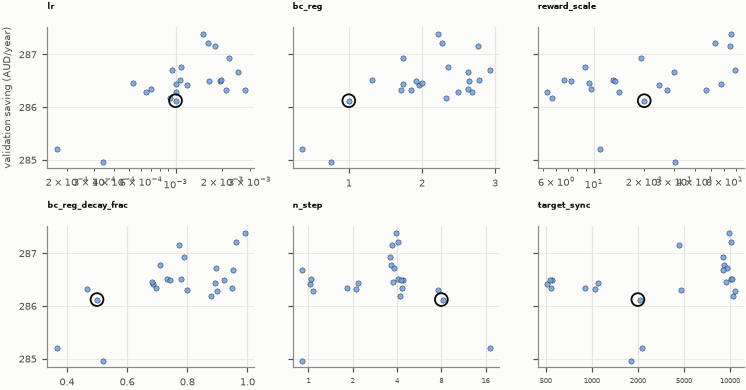

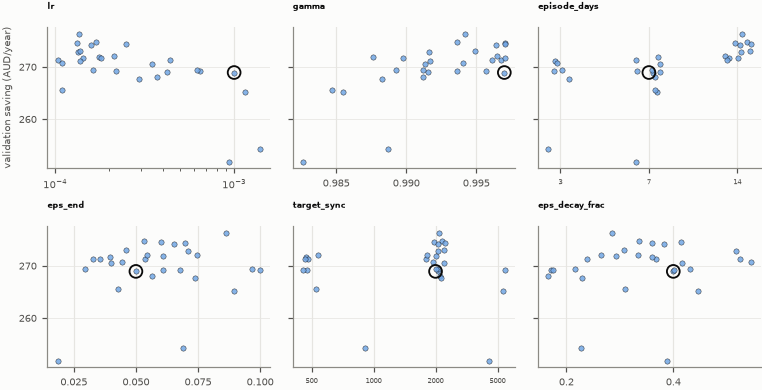

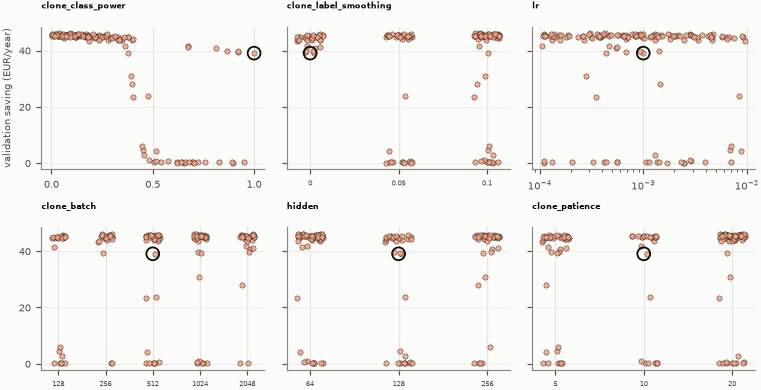

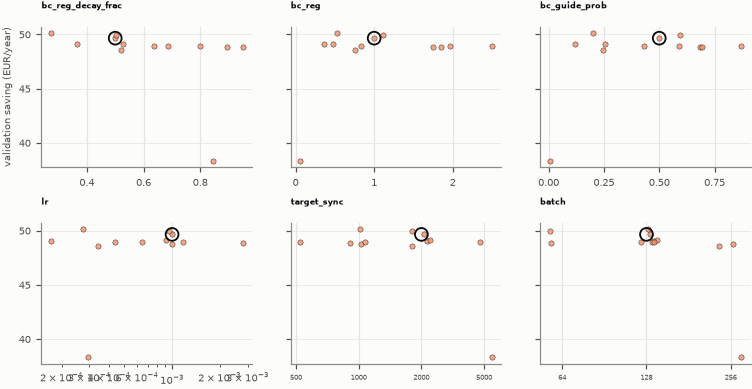

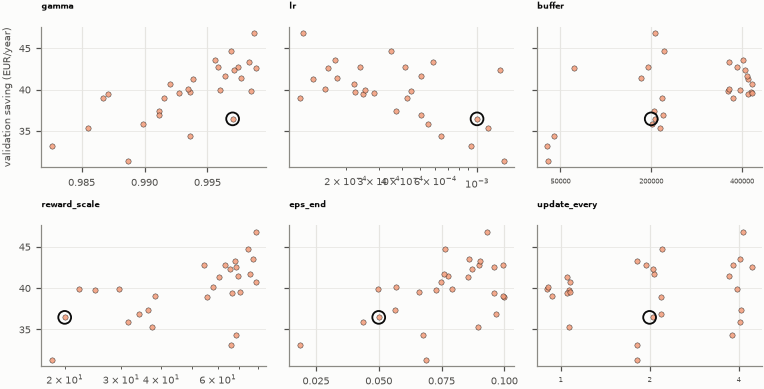

In [4]:
for tariff in TARIFFS:
    for m in METHODS:
        n = study(tariff, m)
        if n is None:
            continue
        sf = hpo.slice_frame(n)
        if sf.empty or sf.x.nunique() < 2:
            continue
        imp = IMP.get(n)
        params = (imp.sort_values("importance", ascending=False).param.tolist()
                  if imp is not None and not imp.empty
                  else list(dict.fromkeys(sf.param)))[:6]
        fig, axes = pf.panel_grid(len(params), ncols=3, sharex=False, sharey=True)
        for ax, p in zip(axes, params):
            d = sf[sf.param == p]
            cat = d.kind.iloc[0] == "cat"
            xs = d.x.astype(float)
            if cat:
                # Categories at their own values, spread a little so equal
                # values stay visible.
                rng = np.random.default_rng(0)
                levels = sorted(set(xs))
                pos = {v: i for i, v in enumerate(levels)}
                xp = xs.map(pos) + rng.uniform(-0.15, 0.15, len(xs))
                ax.set_xticks(range(len(levels)))
                ax.set_xticklabels([f"{v:g}" for v in levels], fontsize=7)
            else:
                xp = xs
                if d.kind.iloc[0] == "log":
                    ax.set_xscale("log")
            ax.scatter(xp, d.value, s=12, color=mcolor(tariff, m),
                       edgecolor=INK, lw=0.3, alpha=0.85)
            inc = d[d.incumbent]
            if len(inc):
                xi = (inc.x.astype(float).map(pos) if cat else inc.x.astype(float))
                ax.scatter(xi, inc.value, s=70, facecolor="none", edgecolor=INK,
                           lw=1.2, zorder=4)
            ax.set_title(p, fontsize=8, loc="left")
            ax.grid(axis="y", color=pf.GRID, lw=0.5)
        axes[0].set_ylabel(f"validation saving ({hs.money(tariff, 'year')})")
        pf.chart_frame(fig, f"{tariff} {METHOD_NAME[m]}: validation saving by setting "
                            f"(ringed: the current settings)")
        pf.show(fig, f"rlhpo_slices_{tariff.lower()}_{m}", layout="frame")

## 4. Refinement: is the search's best more than a lucky seed?

The incumbent and the three best complete trials, re-trained under seeds 0, 1 and 2 on
the search households. Each row is the seed-averaged validation saving minus the
incumbent's, mean over the households with a 95 % bootstrap interval; the filled
marker is the winner. A winner whose interval straddles zero won the search by luck
of the draw, and confirmation will most likely say so too.

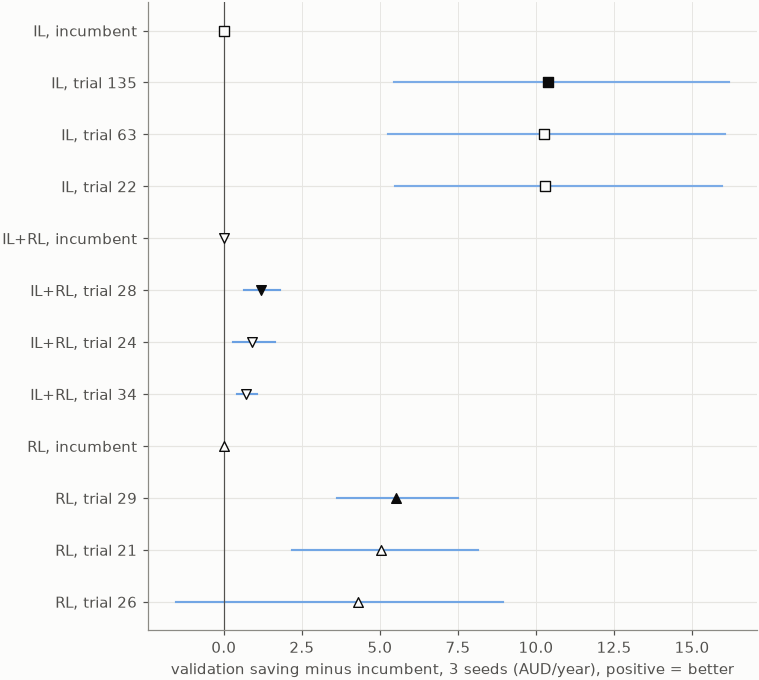

method     label  winner  incumbent  mean    lo    hi  better  n
    bc incumbent   False       True  0.00  0.00  0.00       0 16
    bc trial 135    True      False 10.39  5.46 16.19      16 16
    bc  trial 63   False      False 10.26  5.26 16.05      15 16
    bc  trial 22   False      False 10.29  5.50 15.97      16 16
bc_dqn incumbent   False       True  0.00  0.00  0.00       0  8
bc_dqn  trial 28    True      False  1.18  0.64  1.79       8  8
bc_dqn  trial 24   False      False  0.90  0.28  1.63       7  8
bc_dqn  trial 34   False      False  0.71  0.43  1.05       8  8
   dqn incumbent   False       True  0.00  0.00  0.00       0  8
   dqn  trial 29    True      False  5.52  3.62  7.50       8  8
   dqn  trial 21   False      False  5.05  2.19  8.16       7  8
   dqn  trial 26   False      False  4.29 -1.55  8.95       6  8


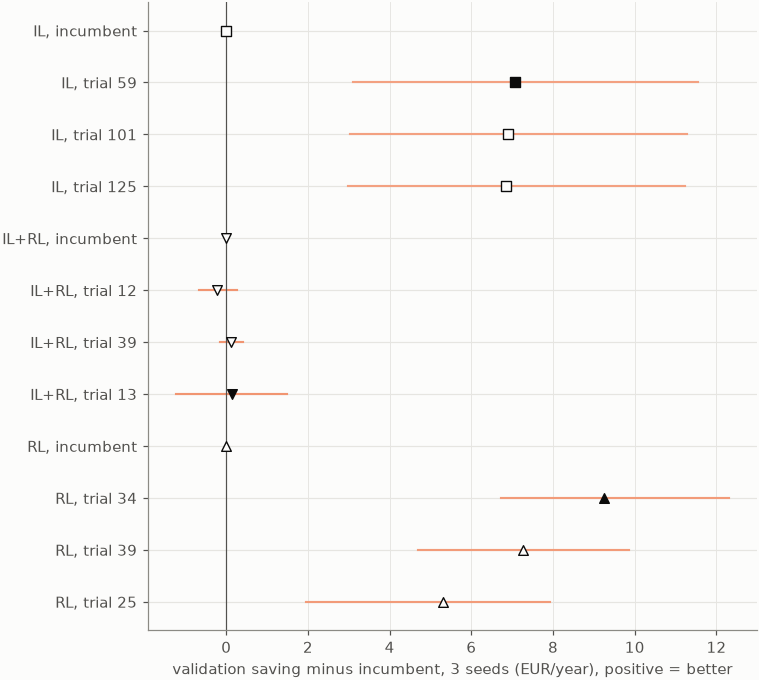

method     label  winner  incumbent  mean    lo    hi  better  n
    bc incumbent   False       True  0.00  0.00  0.00       0 16
    bc  trial 59    True      False  7.07  3.10 11.55      15 16
    bc trial 101   False      False  6.90  3.03 11.27      16 16
    bc trial 125   False      False  6.84  2.98 11.23      15 16
bc_dqn incumbent   False       True  0.00  0.00  0.00       0  8
bc_dqn  trial 12   False      False -0.22 -0.66  0.25       3  8
bc_dqn  trial 39   False      False  0.11 -0.15  0.40       4  8
bc_dqn  trial 13    True      False  0.14 -1.24  1.48       4  8
   dqn incumbent   False       True  0.00  0.00  0.00       0  8
   dqn  trial 34    True      False  9.26  6.72 12.31       8  8
   dqn  trial 39   False      False  7.26  4.71  9.87       8  8
   dqn  trial 25   False      False  5.30  1.95  7.92       7  8


In [5]:
REF = {n: hpo.refine_frame(n) for n in STUDIES}
for tariff in TARIFFS:
    rows = []
    for m in METHODS:
        n = study(tariff, m)
        if n is None or REF[n].empty:
            continue
        r = REF[n]
        wide = r.pivot(index="ident", columns="tag", values="saving_val_a")
        inc_tag = r[r.incumbent].tag.iloc[0]
        for tag, g in r.groupby("tag", sort=False):
            d = (wide[tag] - wide[inc_tag]).to_numpy()
            lo, hi = fs.boot_ci(d, stat=np.mean)
            rows.append({"method": m, "label": g.label.iloc[0], "winner": g.winner.iloc[0],
                         "incumbent": tag == inc_tag, "mean": d.mean(), "lo": lo, "hi": hi,
                         "better": int((d > 0).sum()), "n": len(d)})
    if not rows:
        print(f"{tariff}: no study refined yet")
        continue
    P = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.18 + 0.06 * len(P)))
    y = np.arange(len(P))[::-1]
    for yi, (_, r) in zip(y, P.iterrows()):
        col = mcolor(tariff, r.method)
        if r.lo == r.lo:
            ax.plot([r.lo, r.hi], [yi, yi], color=col, lw=1.4)
        ax.scatter([r["mean"]], [yi], marker=mmarker(r.method), s=40, zorder=3,
                   facecolor=INK if r.winner else SURFACE, edgecolor=INK, lw=0.9)
    ax.axvline(0, color=INK_2, lw=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{METHOD_NAME[r.method]}, {r.label}" for _, r in P.iterrows()])
    ax.grid(axis="x", color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    finish(ax, title=f"{tariff}: refined candidates against the current settings",
           xlabel=f"validation saving minus incumbent, 3 seeds "
                  f"({hs.money(tariff, 'year')}), positive = better", ylabel="")
    pf.show(fig, f"rlhpo_refine_{tariff.lower()}")
    with pd.option_context("display.width", 200):
        print(P.round(2).to_string(index=False))

## 5. Confirmation on the test year

The verdict. On each of the 30 study households, the winner and the panel's current
settings are each trained under three seeds and scored on the **test year** through the
study's own runner and settlement (SI: the endogenous contract included). The row is
the per-household gain in what the household pays per year — bill plus lifetime wear —
averaged over the seeds: positive means the tuned settings save more. Filled =
significant after Holm over all rows; the count on the right is how many of the 30
households gain.

The **grey rows and band** are the noise floor: the *current* settings re-trained under
seed 1 and seed 2, against seed 0. A single re-seed is noisier than a three-seed
average, so the band is a conservative yardstick: a winner inside it has not shown
that it is better than re-rolling the current model.

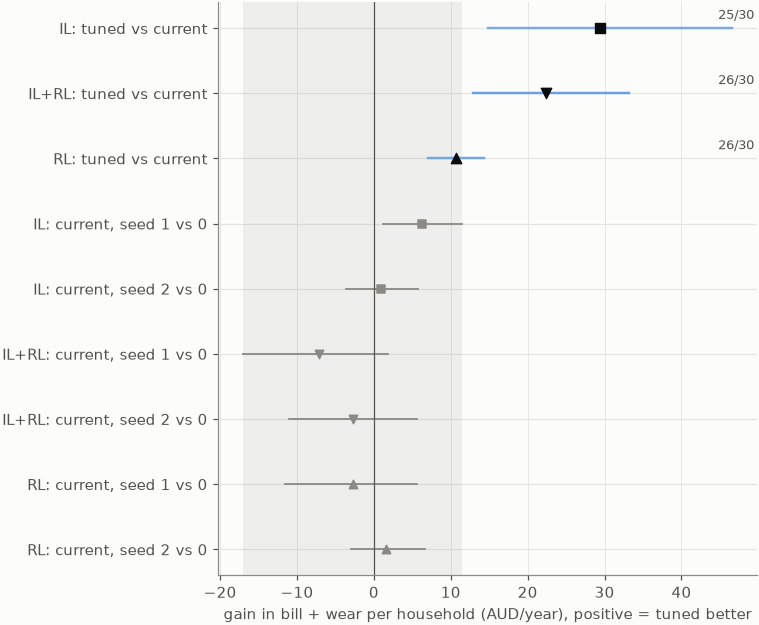

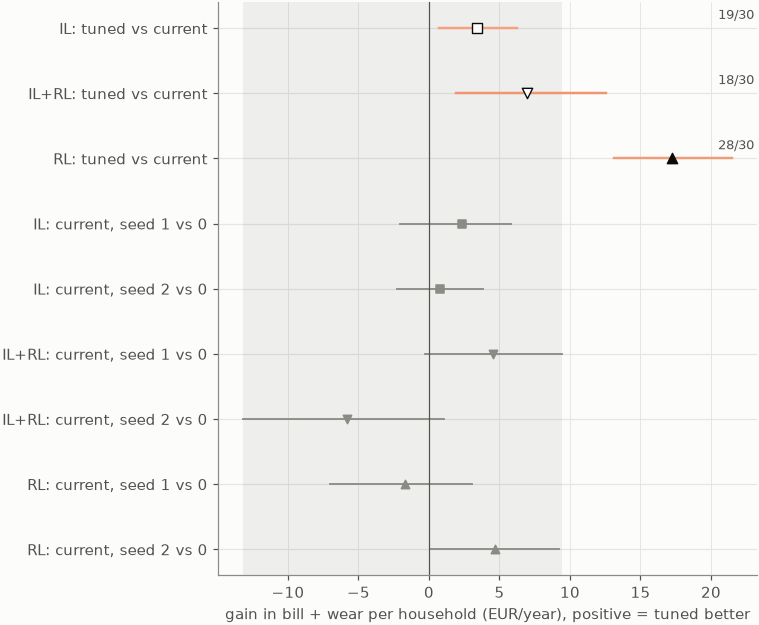

    study tariff method  n  seeds   gain     lo     hi     p  n_better  efc_current  efc_winner  p_holm
    AU_bc     AU     bc 30      3 29.432 14.831 46.613 0.000        25      190.858     191.437   0.000
AU_bc_dqn     AU bc_dqn 30      3 22.438 12.836 33.189 0.000        26      193.040     189.203   0.000
   AU_dqn     AU    dqn 30      3 10.688  6.994 14.330 0.000        26      180.700     171.390   0.000
    SI_bc     SI     bc 30      3  3.390  0.701  6.221 0.045        19      126.999      89.835   0.090
SI_bc_dqn     SI bc_dqn 30      3  6.967  1.945 12.535 0.105        18      115.486      95.423   0.105
   SI_dqn     SI    dqn 30      3 17.262 13.143 21.512 0.000        28       82.862     131.338   0.000


In [6]:
CONF = hpo.confirm_summary()
if CONF.empty:
    print("no study confirmed yet (run `python3 run_rl_hpo.py confirm`)")
else:
    for tariff in TARIFFS:
        C = CONF[CONF.tariff == tariff]
        if C.empty:
            continue
        noise = []
        for n in C.study:
            cf_ = hpo.confirm_frame(n)
            cur = (cf_[cf_.label == "current"]
                   .pivot(index="ident", columns="seed", values="test_net"))
            for s in (1, 2):
                if s in cur and 0 in cur:
                    d = (cur[0] - cur[s]).dropna().to_numpy()
                    lo, hi = fs.boot_ci(d, stat=np.mean)
                    noise.append({"study": n, "method": n.split("_", 1)[1],
                                  "seed": s, "mean": d.mean(), "lo": lo, "hi": hi})
        N = pd.DataFrame(noise)
        n_rows = len(C) + len(N)
        fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.2 + 0.07 * n_rows))
        y = n_rows - 1
        labels = []
        for _, r in C.iterrows():
            col = mcolor(tariff, r.method)
            sig = r.p_holm == r.p_holm and r.p_holm < 0.05
            ax.plot([r.lo, r.hi], [y, y], color=col, lw=1.6)
            ax.scatter([r.gain], [y], marker=mmarker(r.method), s=46, zorder=3,
                       facecolor=INK if sig else SURFACE, edgecolor=INK, lw=0.9)
            pf.edge_label(ax, y, f"{r.n_better}/{r.n}", side="right")
            labels.append((y, f"{METHOD_NAME[r.method]}: tuned vs current"))
            y -= 1
        for _, r in N.iterrows():
            ax.plot([r.lo, r.hi], [y, y], color=MUTED, lw=1.2)
            ax.scatter([r["mean"]], [y], marker=mmarker(r.method), s=30,
                       color=MUTED, zorder=3)
            labels.append((y, f"{METHOD_NAME[r.method]}: current, seed {r.seed} vs 0"))
            y -= 1
        if not N.empty:
            ax.axvspan(N.lo.min(), N.hi.max(), color=MUTED, alpha=0.12, lw=0)
        ax.axvline(0, color=INK_2, lw=0.8)
        ax.set_yticks([p for p, _ in labels])
        ax.set_yticklabels([s for _, s in labels])
        ax.grid(axis="x", color=pf.GRID, lw=0.6)
        ax.set_axisbelow(True)
        finish(ax, title=f"{tariff}: tuned against current settings, test year",
               xlabel=f"gain in bill + wear per household ({hs.money(tariff, 'year')}), "
                      f"positive = tuned better", ylabel="")
        pf.show(fig, f"rlhpo_confirm_{tariff.lower()}")
    with pd.option_context("display.width", 200):
        print(CONF.drop(columns=["d"]).round(3).to_string(index=False))

## 6. What the winners changed

Each refined winner next to the setting it would replace. Only rows that differ are
shown. The last line of the cell is what `run_rl_hpo.py report` prints for
`run_rl_benchmark.TUNED`.

In [7]:
rows = []
for n in STUDIES:
    w = hpo.winner(n)
    if w is None:
        continue
    s = hpo.read_settings(n)
    for p, cur in s["incumbent_params"].items():
        new = w["overrides"].get(p, cur)
        if new != cur:
            rows.append({"study": n, "param": p, "current": cur, "winner": new})
    for p, v in (s.get("fixed") or {}).items():
        rows.append({"study": n, "param": f"{p} (fixed clone)", "current": "",
                     "winner": v})
CHANGES = pd.DataFrame(rows)
if CHANGES.empty:
    print("no winners yet")
else:
    with pd.option_context("display.width", 200, "display.max_rows", 200):
        print(CHANGES.to_string(index=False))
print("\nTUNED entries for the winners:")
print(hpo.tuned_entries() or "    (none yet)")

    study                               param current        winner
    AU_bc                                  lr   0.001      0.003562
    AU_bc                              hidden     128     64.000000
    AU_bc                         clone_batch     512    128.000000
    AU_bc                  clone_weight_decay     0.0      0.000100
    AU_bc                   clone_class_power     1.0      0.135694
    AU_bc               clone_label_smoothing     0.0      0.050000
    AU_bc                      clone_patience      10      5.000000
AU_bc_dqn                                  lr   0.001      0.001502
AU_bc_dqn                               gamma   0.997      0.993265
AU_bc_dqn                              n_step       8      4.000000
AU_bc_dqn                               batch     128    256.000000
AU_bc_dqn                         target_sync    2000  10000.000000
AU_bc_dqn                      eps_decay_frac     0.4      0.294083
AU_bc_dqn                        reward_scale   